⚠️ Figshare NOT found. Cross-dataset analysis will be skipped.
   Upload Figshare as a Kaggle Dataset and re-run for full 8.5.

PART 1: Training MobileNetV2 (Seed 42)


/tmp/ipykernel_58/133665613.py:54: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
I0000 00:00:1785671546.954403      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785671546.957479      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/30


2026-08-02 11:52:54.086451: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 11:52:54.224126: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1785671581.423962     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 140s 786ms/step - accuracy: 0.7533 - loss: 0.7329 - val_accuracy: 0.7330 - val_loss: 0.7298 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 532ms/step - accuracy: 0.8873 - loss: 0.3220 - val_accuracy: 0.7893 - val_loss: 0.6761 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 532ms/step - accuracy: 0.9205 - loss: 0.2250 - val_accuracy: 0.8277 - val_loss: 0.6003 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 539ms/step - accuracy: 0.9422 - loss: 0.1640 - val_accuracy: 0.8643 - val_loss: 0.4823 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 532ms/step - accuracy: 0.9556 - loss: 0.1300 - val_accuracy: 0.9107 - val_loss: 0.3430 - learning_rate: 1.0000e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 536ms/step - accuracy: 0.9578 - loss: 0.1291 - val_accuracy: 0.9116 - val_loss: 0.2899 - learning_rate: 1.0000e-04
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 528ms/step -

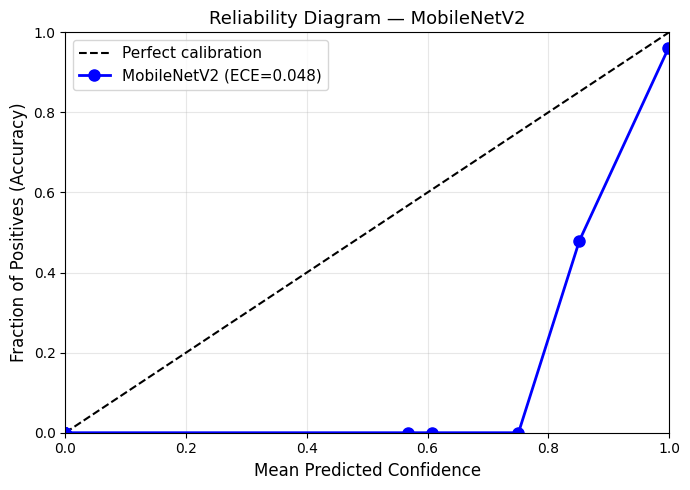

Saved: reliability_diagram.png

PART 3: Bootstrap 95% Confidence Intervals (10,000 samples)

📊 TABLE FOR PAPER:
Overall Accuracy: 94.69%
  95% Bootstrap CI: [93.56%, 95.75%]

Per-Class Recall 95% CIs:
  glioma      : [79.26%, 86.58%]
  meningioma  : [94.25%, 98.00%]
  notumor     : [100.00%, 100.00%]
  pituitary   : [98.69%, 100.00%]

⚠️ Skipping Part 4 (Cross-Dataset) — Figshare not found.

PART 5: High-Confidence Error Analysis
Mean confidence (correct):   0.9982
Mean confidence (incorrect): 0.9326
Fraction of errors with confidence > 0.9: 74.12%


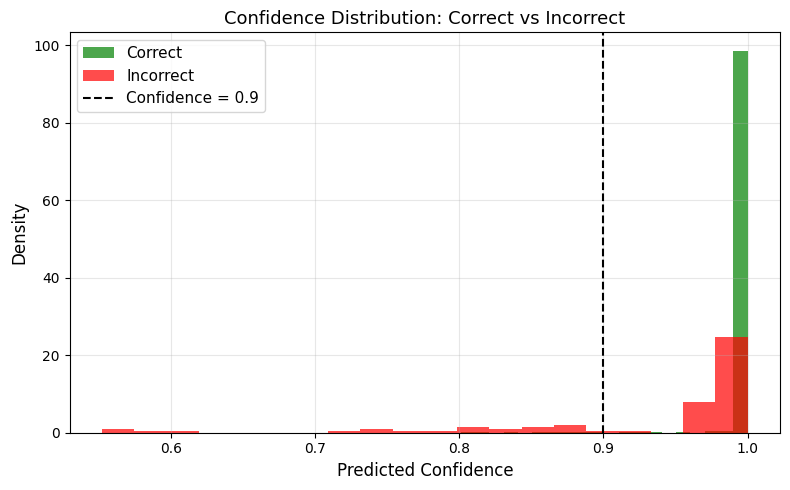

Saved: confidence_error_analysis.png

✅ DONE
Download from /kaggle/working/:
  1. reliability_diagram.png
  2. confidence_error_analysis.png

Paste the printed tables into your paper.


In [1]:
import os, numpy as np, tensorflow as tf, cv2
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pre_mob
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from scipy import stats

tf.get_logger().setLevel('ERROR')
np.random.seed(42)
tf.random.set_seed(42)

# ========== PATHS ==========
BASE = '/kaggle/input/datasets/ekrasafdar/brain-tumor-mri'
TRAIN_DIR = os.path.join(BASE, 'Training')
TEST_DIR  = os.path.join(BASE, 'Testing')

# Auto-find Figshare (any folder with glioma/meningioma/pituitary but NOT notumor)
FIGSHARE_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    for d in dirs:
        path = os.path.join(root, d)
        try:
            sub = [s for s in os.listdir(path) if os.path.isdir(os.path.join(path, s))]
            # Figshare has glioma, meningioma, pituitary but NO notumor
            if set(['glioma', 'meningioma', 'pituitary']).issubset(set([s.lower() for s in sub])):
                if 'notumor' not in [s.lower() for s in sub]:
                    FIGSHARE_DIR = path
                    print(f"✅ Found Figshare: {FIGSHARE_DIR}")
                    print(f"   Classes: {sub}")
                    break
        except:
            pass
    if FIGSHARE_DIR:
        break

if not FIGSHARE_DIR:
    print("⚠️ Figshare NOT found. Cross-dataset analysis will be skipped.")
    print("   Upload Figshare as a Kaggle Dataset and re-run for full 8.5.\n")

IMG_SIZE = (224, 224)
BATCH = 32

# ============================================
# PART 1: TRAIN MOBILENETV2 (~15 min)
# ============================================
print("="*60)
print("PART 1: Training MobileNetV2 (Seed 42)")
print("="*60)

inp = layers.Input(shape=(224, 224, 3))
base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
base.trainable = True
for L in base.layers[:-50]: 
    L.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(4, activation='softmax')(x)
model = keras.Model(inp, out)
model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

tr_aug = ImageDataGenerator(
    preprocessing_function=pre_mob, rotation_range=20,
    width_shift_range=0.15, height_shift_range=0.15, zoom_range=0.15,
    horizontal_flip=True, brightness_range=[0.8, 1.2], validation_split=0.2)

tr = tr_aug.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='training', seed=42)
val = tr_aug.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='validation', shuffle=False, seed=42)
te = ImageDataGenerator(preprocessing_function=pre_mob).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH, 
    class_mode='categorical', shuffle=False)

cb = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, 
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                                       patience=4, verbose=1)
]
model.fit(tr, validation_data=val, epochs=30, callbacks=cb, verbose=1)

te.reset()
y_prob = model.predict(te, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = te.classes
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

acc = np.mean(y_pred == y_true)
print(f"\nPrimary Test — Accuracy: {acc*100:.2f}%")

# ============================================
# PART 2: CALIBRATION (ECE + Reliability Diagram)
# ============================================
print("\n" + "="*60)
print("PART 2: Model Calibration (ECE + Reliability Diagram)")
print("="*60)

def compute_ece(y_true, y_prob, n_bins=10):
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    accuracies = (predictions == y_true).astype(float)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_accs, bin_confs, bin_counts = [], [], []
    
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        prop = np.mean(in_bin)
        if prop > 0:
            acc = np.mean(accuracies[in_bin])
            conf = np.mean(confidences[in_bin])
            ece += np.abs(conf - acc) * prop
            bin_accs.append(acc)
            bin_confs.append(conf)
            bin_counts.append(np.sum(in_bin))
        else:
            bin_accs.append(0)
            bin_confs.append(0)
            bin_counts.append(0)
    return ece, bin_accs, bin_confs, bin_counts

ece, bin_accs, bin_confs, bin_counts = compute_ece(y_true, y_prob, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(bin_confs, bin_accs, 'o-', color='blue', markersize=8, linewidth=2, 
        label=f'MobileNetV2 (ECE={ece:.3f})')
ax.set_xlabel('Mean Predicted Confidence', fontsize=12)
ax.set_ylabel('Fraction of Positives (Accuracy)', fontsize=12)
ax.set_title('Reliability Diagram — MobileNetV2', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('/kaggle/working/reliability_diagram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: reliability_diagram.png")

# ============================================
# PART 3: BOOTSTRAP 95% CONFIDENCE INTERVALS
# ============================================
print("\n" + "="*60)
print("PART 3: Bootstrap 95% Confidence Intervals (10,000 samples)")
print("="*60)

def bootstrap_ci(y_true, y_pred, class_names, n_bootstrap=10000):
    rng = np.random.default_rng(42)
    n = len(y_true)
    
    # Overall accuracy CI
    acc_samples = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        acc_samples.append(np.mean(y_true[idx] == y_pred[idx]))
    acc_ci = np.percentile(acc_samples, [2.5, 97.5])
    
    # Per-class recall CI
    class_cis = {}
    for c, name in enumerate(class_names):
        recall_samples = []
        for _ in range(n_bootstrap):
            idx = rng.integers(0, n, n)
            yt_b, yp_b = y_true[idx], y_pred[idx]
            mask = yt_b == c
            if np.sum(mask) > 0:
                recall_samples.append(np.mean(yp_b[mask] == c))
            else:
                recall_samples.append(0)
        class_cis[name] = np.percentile(recall_samples, [2.5, 97.5])
    
    return acc_ci, class_cis

acc_ci, class_cis = bootstrap_ci(y_true, y_pred, class_names)
print(f"\n📊 TABLE FOR PAPER:")
print(f"Overall Accuracy: {acc*100:.2f}%")
print(f"  95% Bootstrap CI: [{acc_ci[0]*100:.2f}%, {acc_ci[1]*100:.2f}%]")
print(f"\nPer-Class Recall 95% CIs:")
for name, ci in class_cis.items():
    print(f"  {name:<12}: [{ci[0]*100:.2f}%, {ci[1]*100:.2f}%]")

# ============================================
# PART 4: CROSS-DATASET (Only if Figshare found)
# ============================================
if FIGSHARE_DIR:
    print("\n" + "="*60)
    print("PART 4: Cross-Dataset Evaluation + Grad-CAM")
    print("="*60)
    
    figshare_gen = ImageDataGenerator(preprocessing_function=pre_mob).flow_from_directory(
        FIGSHARE_DIR, target_size=IMG_SIZE, batch_size=BATCH, 
        class_mode='categorical', shuffle=False)
    
    figshare_gen.reset()
    fs_prob = model.predict(figshare_gen, verbose=0)
    fs_pred = np.argmax(fs_prob, axis=1)
    fs_true = figshare_gen.classes
    fs_classes = list(figshare_gen.class_indices.keys())
    
    print(f"\nFigshare Classes: {fs_classes}")
    print(f"Overall Cross-Dataset Accuracy: {np.mean(fs_pred==fs_true)*100:.2f}%")
    print("\n📋 TABLE FOR PAPER (Cross-Dataset Per-Class):")
    print(f"{'Class':<15} {'Accuracy':<12} {'Support'}")
    print("-"*40)
    for i, cls in enumerate(fs_classes):
        mask = fs_true == i
        acc_cls = np.mean(fs_pred[mask] == i) if np.sum(mask) > 0 else 0
        print(f"{cls:<15} {acc_cls*100:.2f}%       {np.sum(mask)}")
    
    # Cross-dataset Grad-CAM
    def make_gradcam_model():
        return keras.Model(inputs=model.inputs,
            outputs=[model.get_layer('out_relu').output, model.output])
    
    def gradcam(grad_model, img_array, pred_index=None):
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        return heatmap.numpy()
    
    def overlay_heatmap(img_path, heatmap, alpha=0.4):
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        heatmap = cv2.resize(heatmap, (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
        return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)
    
    representatives = {}
    for i in range(len(figshare_gen)):
        x, y = figshare_gen[i]
        cls_idx = np.argmax(y[0])
        cls_name = fs_classes[cls_idx]
        if cls_name not in representatives:
            representatives[cls_name] = (x[0], figshare_gen.filepaths[i])
        if len(representatives) == len(fs_classes):
            break
    
    grad_model = make_gradcam_model()
    fig, axes = plt.subplots(1, len(fs_classes), figsize=(15, 5))
    if len(fs_classes) == 1:
        axes = [axes]
    
    for idx, cls in enumerate(fs_classes):
        img_raw, path = representatives[cls]
        img_pre = pre_mob(img_raw.copy())
        img_batch = np.expand_dims(img_pre, axis=0)
        heatmap = gradcam(grad_model, img_batch)
        overlay = overlay_heatmap(path, heatmap)
        axes[idx].imshow(overlay)
        axes[idx].set_title(f'Figshare: {cls}', fontsize=12)
        axes[idx].axis('off')
    
    plt.suptitle('Cross-Dataset Grad-CAM — MobileNetV2 (Zero-Shot)', fontsize=14)
    plt.tight_layout()
    plt.savefig('/kaggle/working/gradcam_cross_dataset.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: gradcam_cross_dataset.png")
else:
    print("\n⚠️ Skipping Part 4 (Cross-Dataset) — Figshare not found.")

# ============================================
# PART 5: CONFIDENCE ERROR ANALYSIS
# ============================================
print("\n" + "="*60)
print("PART 5: High-Confidence Error Analysis")
print("="*60)

confidences = np.max(y_prob, axis=1)
correct_mask = (y_pred == y_true)
wrong_mask = ~correct_mask

print(f"Mean confidence (correct):   {np.mean(confidences[correct_mask]):.4f}")
print(f"Mean confidence (incorrect): {np.mean(confidences[wrong_mask]):.4f}")
print(f"Fraction of errors with confidence > 0.9: {np.mean(confidences[wrong_mask] > 0.9):.2%}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(confidences[correct_mask], bins=20, alpha=0.7, label='Correct', color='green', density=True)
ax.hist(confidences[wrong_mask], bins=20, alpha=0.7, label='Incorrect', color='red', density=True)
ax.axvline(x=0.9, color='black', linestyle='--', label='Confidence = 0.9')
ax.set_xlabel('Predicted Confidence', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Confidence Distribution: Correct vs Incorrect', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/confidence_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: confidence_error_analysis.png")

print("\n" + "="*60)
print("✅ DONE")
print("="*60)
print("Download from /kaggle/working/:")
print("  1. reliability_diagram.png")
print("  2. confidence_error_analysis.png")
if FIGSHARE_DIR:
    print("  3. gradcam_cross_dataset.png")
print("\nPaste the printed tables into your paper.")